In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph
from pydrake.systems.framework import DiagramBuilder
from pydrake.multibody.parsing import Parser
import os
from pydrake.all import (
    LoadModelDirectives, ProcessModelDirectives, RevoluteJoint, 
    RationalForwardKinematics, CspaceFreePolytope, SeparatingPlaneOrder,
    RigidTransform, RotationMatrix, Rgba,
    AffineSubspace, MathematicalProgram, Solve,
    MeshcatVisualizer, StartMeshcat,
    LoadIrisRegionsYamlFile, ModelVisualizer,
    PointCloud
)
import numpy as np
# from pydrake.geometry.optimization_dev import (CspaceFreePolytope, SeparatingPlaneOrder)
from iris_plant_visualizer import IrisPlantVisualizer
from pydrake.geometry import Role
from pydrake.geometry.optimization import IrisOptions, HPolyhedron, Hyperellipsoid, IrisInRationalConfigurationSpace
from pydrake.solvers import MosekSolver, CommonSolverOption, SolverOptions, ScsSolver
import time
from pgd import *

from manipulation.utils import ConfigureParser
from manipulation.scenarios import AddPlanarIiwa, AddShape, AddWsg
import sys

# set up the certifier and the options for different search techniques
solver_options = SolverOptions()
# set this to 1 if you would like to see the solver output in terminal.
solver_options.SetOption(CommonSolverOption.kPrintToConsole, 1)

os.environ["MOSEKLM_LICENSE_FILE"] = "/home/sgrg/mosek.lic"
with open(os.environ["MOSEKLM_LICENSE_FILE"], 'r') as f:
    contents = f.read()
    mosek_file_not_empty = contents != ''
print(mosek_file_not_empty)

solver_id = MosekSolver.id() if MosekSolver().available() and mosek_file_not_empty else ScsSolver.id()

import logging
dk_log = logging.getLogger("drake")
dk_log.setLevel(logging.DEBUG)
dk_log.getChild("Snopt").setLevel(logging.INFO)

True


In [3]:
#construct our robot
from pydrake.all import InverseKinematics, Sphere

builder = DiagramBuilder()

plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)
ConfigureParser(parser)
iiwa = AddPlanarIiwa(plant)
wsg = AddWsg(plant, iiwa, roll=0.0, welded=True)
sphere = AddShape(plant, Sphere(0.02), "sphere")
X_WO = RigidTransform([0.6, 0, 0.65])
plant.WeldFrames(plant.world_frame(), plant.GetFrameByName("sphere"), X_WO)
bi = parser.AddModelsFromUrl("package://manipulation/shelves.sdf")[0]
plant.WeldFrames(
    plant.world_frame(),
    plant.GetFrameByName("shelves_body", bi),
    RigidTransform([0.8, 0, 0.4]),
    )

plant.Finalize()
meshcat = StartMeshcat()
MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
diagram = builder.Build()

context = diagram.CreateDefaultContext()
plant_context = plant.GetMyContextFromRoot(context)

q0 = plant.GetPositions(plant_context)
gripper_frame = plant.GetFrameByName("body", wsg)
sphere_frame = plant.GetFrameByName("sphere", sphere)

ik = InverseKinematics(plant, plant_context)
collision_constraint = ik.AddMinimumDistanceLowerBoundConstraint(0.001, 0.01)
grasp_constraint = ik.AddPositionConstraint(
    gripper_frame, [0, 0.1, 0], sphere_frame, [0, 0, 0], [0, 0, 0]
)

prog = ik.get_mutable_prog()
q = ik.q()
prog.SetInitialGuess(q, q0)
result = Solve(ik.prog())
if not result.is_success():
    print("IK failed")

diagram.ForcedPublish(context)

Ratfk = RationalForwardKinematics(plant)

# the point about which we will take the stereographic projections
# q_star = np.zeros(plant.num_positions())
q_star = np.array([0.0,0.0,0.0])
do_viz = True

# The object we will use to perform our certification.
cspace_free_polytope = CspaceFreePolytope(plant, scene_graph, SeparatingPlaneOrder.kAffine, q_star)

DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:readlink(/proc/self/exe) = /usr/bin/python3.10
DEBUG:drake:FindRunfile mechanism = argv0
DEBUG:drake:cwd = "/home/sgrg/rlg/SUPERUROP/ciris"
DEBUG:drake:FindRunfile error: ERROR: external/bazel_tools/tools/cpp/runfiles/runfiles.cc(123): cannot find runfiles (argv0="/usr/bin/python3.10") (created using argv0 with TEST_SRCDIR=nullptr and RUNFILES_MANIFEST_FILE=nullptr and RUNFILES_DIR=nullptr)
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-packages/pydrake/common/../../../..'
DEBUG:drake:FindResource ignoring DRAKE_RESOURCE_ROOT because it is not set.
DEBUG:drake:FindResource libdrake_dir='/home/sgrg/rlg/drake-build/install/lib/python3.10/site-package

In [4]:
for varq in q:
    print(result.GetSolution(varq))

0.22779647389084973
-1.033717515079888
1.404285299646268


In [5]:
def visualise_IRIS(regions, plant, plant_context, seed=42, num_sample=10000, colors=None):       
    world_frame = plant.world_frame()
    ee_frame = plant.GetFrameByName("iiwa_frame_ee")

    rng = RandomGenerator(seed)

    # Allow caller to input custom colors
    if colors is None:
        colors = [
                    Rgba(0.5,0.0,0.0,0.5),
                    Rgba(0.0,0.5,0.0,0.5),
                    Rgba(0.0,0.0,0.5,0.5),
                    Rgba(0.5,0.5,0.0,0.5),
                    Rgba(0.5,0.0,0.5,0.5),
                    Rgba(0.0,0.5,0.5,0.5),
                    Rgba(0.2,0.2,0.2,0.5),
                    Rgba(0.5,0.2,0.0,0.5),
                    Rgba(0.2,0.5,0.0,0.5),
                    Rgba(0.5,0.0,0.2,0.5),
                    Rgba(0.2,0.0,0.5,0.5),
                    Rgba(0.0,0.5,0.2,0.5),
                    Rgba(0.0,0.2,0.5,0.5),
                ]

    for i in range(len(regions)):
        region = regions[i]

        xyzs = []  # List to hold XYZ positions of configurations in the IRIS region

        rq_sample = region.UniformSample(rng)
        q_sample = Ratfk.ComputeQValue(rq_sample, q_star)

        plant.SetPositions(plant_context, q_sample)
        xyzs.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())

        for _ in range(num_sample-1):
            prev_sample = rq_sample
            rq_sample = region.UniformSample(rng, prev_sample)
            q_sample = Ratfk.ComputeQValue(rq_sample, q_star)

            plant.SetPositions(plant_context, q_sample)
            xyzs.append(plant.CalcRelativeTransform(plant_context, frame_A=world_frame, frame_B=ee_frame).translation())

        # Create pointcloud from sampled point in IRIS region in order to plot in Meshcat
        xyzs = np.array(xyzs)
        pc = PointCloud(len(xyzs))
        pc.mutable_xyzs()[:] = xyzs.T
        meshcat.SetObject(f"regions/region {i}", pc, point_size=0.025, rgba=colors[i % len(colors)])

In [6]:
iris_options = IrisOptions()
iris_options.require_sample_point_is_contained = True
iris_options.configuration_space_margin = 0.0001
iris_options.relative_termination_threshold = 0.001
iris_options.iteration_limit = 10

def in_collision(plant, scene_graph, context, print_collisions=False, thresh=1e-3):
    plant_context = plant.GetMyContextFromRoot(context)
    sg_context = scene_graph.GetMyContextFromRoot(context)
    query_object = plant.get_geometry_query_input_port().Eval(plant_context)
    inspector = scene_graph.get_query_output_port().Eval(sg_context).inspector()
    pairs = inspector.GetCollisionCandidates()
    dists = []
    for pair in pairs:
        dists.append(query_object.ComputeSignedDistancePairClosestPoints(pair[0], pair[1]).distance)
        if dists[-1] < thresh and print_collisions:
            print(inspector.GetName(inspector.GetFrameId(pair[0])),
                  inspector.GetName(inspector.GetFrameId(pair[1])))
    return np.min(dists) < thresh

def grow_region(q):
    name = str(q)    
    t1 = time.time()
    plant.SetPositions(plant.GetMyMutableContextFromRoot(context), q)
    r = IrisInRationalConfigurationSpace(plant, 
                                         plant.GetMyContextFromRoot(context),
                                         q_star, iris_options)
    t2 = time.time()
    print("Region constructed in ~%d seconds." % int(t2 - t1))
    return r

In [16]:
from pydrake.all import LoadIrisRegionsYamlFile
regs = LoadIrisRegionsYamlFile("/home/sgrg/rlg/SUPERUROP/ciris/1028/certified_regions_2.yaml")
regions = [r for r in regs.values()]

In [17]:
from util import notebook_plot_connectivity

DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will us

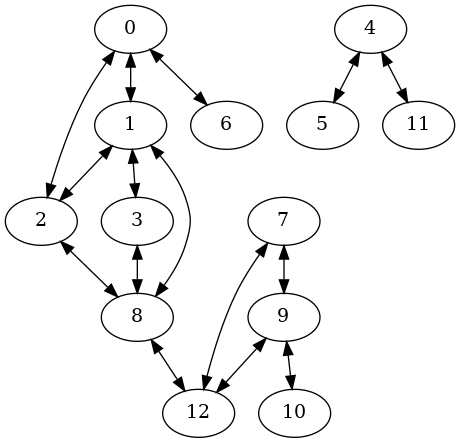

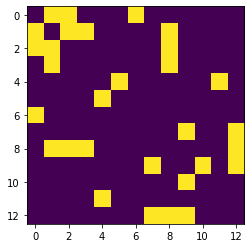

Graph has 2 connected components.


In [18]:
notebook_plot_connectivity(regions)

In [28]:
visualise_IRIS([regions[3], regions[8], regions[5]], plant, plant_context)

DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek
DEBUG:drake:solvers::Solve will use Mosek


In [ ]:
regions[6].IntersectsWith(regions[7])

In [ ]:
from manipulation.exercises.trajectories.rrt_planner.robot import (
    ConfigurationSpace,
    Range,
)
q_low = np.array([-3.094395,-3.094395,-3.094395])
q_high = np.array([3.094395,3.094395,3.094395])

joint_limits = np.zeros((3, 2))
idx, i = 0, 0
for joint_index in plant.GetJointIndices():
    joint = plant.get_mutable_joint(joint_index)
    if isinstance(joint, RevoluteJoint):
        joint.set_default_angle(q0[idx])
        joint.set_position_limits(lower_limits= np.array([q_low[idx]]), upper_limits= np.array([q_high[idx]]))
        idx += 1
        joint_limits[i, 0] = joint.position_lower_limits()
        joint_limits[i, 1] = joint.position_upper_limits()
        i += 1

range_list = []
for joint_limit in joint_limits:
    range_list.append(Range(joint_limit[0], joint_limit[1]))

def l2_distance(q: tuple):
    sum = 0
    for q_i in q:
        sum += q_i**2
    return np.sqrt(sum)

max_steps = 3 * [np.pi / 180 * 2]  # three degrees
cspace = ConfigurationSpace(range_list, l2_distance, max_steps)

In [75]:
l

In [70]:
from random import random
def rrt_planning(max_iterations=100, prob_sample_q_goal=0.05):
    q_start = regions[0].ChebyshevCenter()
    q_goal = [-0.02, -1.96, -0.95]
    rrt_tools = RRT_tools(q_start, cspace, q_goal)

    for i in range(max_iterations):
        print('.', end='')
        q_sample = cspace.sample()
        if random() < prob_sample_q_goal or i == max_iterations - 1:
                q_sample = q_goal
        closest_node = rrt_tools.find_nearest_node_in_RRT_graph(q_sample)
#         print(closest_node.value)
        edge = rrt_tools.calc_intermediate_qs_wo_collision(closest_node.value, q_sample)
#         print(edge)
        last_node = closest_node
        for j in range(1, len(edge)):
            last_node = rrt_tools.grow_rrt_tree(last_node, edge[j])

        if rrt_tools.node_reaches_goal(last_node):
            print("found goal")
            path = rrt_tools.backup_path_from_node(last_node)
            return path
    
    return None

p = rrt_planning()

DEBUG:drake:solvers::Solve will use Mosek


.found this configuration in collision (0.8652624196058105, -1.9176803320067561, -1.358066237545735)
.found this configuration in collision (0.6149253571086447, -1.9271388456034841, -1.4971779785580765)
.found this configuration in collision (0.6025934793032894, -2.076506799201884, -0.8690362395079747)
.found this configuration in collision (0.7216194846443745, -1.73994407319412, -1.4913760349067549)
.found this configuration in collision (0.9053283660553086, -1.632642225344166, -1.3978991199216324)
.found this configuration in collision (0.7581406031105624, -1.5738747118410248, -1.2768270045397414)
.found this configuration in collision (0.7841914505543851, -1.5483436506414314, -1.2415152366596092)
.found this configuration in collision (0.6872719451126728, -1.786509060638665, -1.4228731196582995)
.found this configuration in collision (0.71895818420752, -1.7457494026524372, -1.4431393589870647)
.found this configuration in collision (0.6736663218793136, -1.7664664438309718, -1.462622

.found this configuration in collision (0.739357262992739, -2.453231580879235, -1.9902877631533085)
.found this configuration in collision (0.8431510470193688, -1.9121828582933644, -1.323138643438484)
.found this configuration in collision (0.49577777016138985, -1.7052192188593946, -0.8281685017725755)
.found this configuration in collision (0.7753372205162472, -1.544584700175508, -1.199322356209099)
.found this configuration in collision (0.8603708634095136, -1.5194419124210645, -1.4952902899319311)
.found this configuration in collision (0.6946749074657544, -1.7517968189727813, -1.5176606773393024)
.found this configuration in collision (0.768230142536108, -1.5446292511483328, -1.189545218198123)
.found this configuration in collision (-0.29702451910099315, -2.446879756912865, 0.24857946520178534)
.found this configuration in collision (0.9702125086478289, -1.8228076498268386, -1.5897582342518877)
.found this configuration in collision (0.898158048759572, -1.4244887942222524, -1.0079

In [64]:


def plot_path(q_path, meshcat, IK_obj, name="path", color_rgba=(1, 0, 0, 1)):
    points_local = np.array([IK_obj.FK(q[:7])[:-1,-1] for q in q_path])

    pointcloud = PointCloud(len(points_local))
    pointcloud.mutable_xyzs()[:] = points_local.T
    meshcat.SetObject("paths/" + name, pointcloud, 0.015, rgba=Rgba(*color_rgba))

In [88]:
def calc_intermediate_qs_wo_collision(q_start, q_end):
    """create more samples by linear interpolation from q_start
    to q_end. Return all samples that are not in collision

    Example interpolated path:
    q_start, qa, qb, (Obstacle), qc , q_end
    returns >>> q_start, qa, qb
    """
    path = cspace.path(q_start, q_end)
    print(path)
    safe_path = []
    for configuration in path:
        plant_context = plant.GetMyContextFromRoot(context)
        plant.SetPositions(plant_context, configuration)
        diagram.ForcedPublish(context)
        if in_collision(plant, scene_graph, context):
            print("found this configuration in collision", configuration)
            return safe_path
        safe_path.append(configuration)
    return safe_path

q_start = regions[6].ChebyshevCenter()
q_goal = [-0.02, -1.96, -0.95]
calc_intermediate_qs_wo_collision(q_start, q_goal)

DEBUG:drake:solvers::Solve will use Mosek


[array([ 0.75504394, -1.87988612, -1.49803537]), (0.7198146729822251, -1.8835276638474159, -1.4731246711224486), (0.6845854028402144, -1.8871692036642056, -1.4482139724975702), (0.6493561326982037, -1.8908107434809953, -1.4233032738726916), (0.614126862556193, -1.894452283297785, -1.3983925752478132), (0.5788975924141823, -1.8980938231145748, -1.3734818766229346), (0.5436683222721714, -1.9017353629313645, -1.348571177998056), (0.5084390521301607, -1.9053769027481542, -1.3236604793731777), (0.47320978198815006, -1.909018442564944, -1.298749780748299), (0.43798051184613934, -1.9126599823817336, -1.2738390821234207), (0.4027512417041286, -1.9163015221985233, -1.248928383498542), (0.3675219715621179, -1.919943062015313, -1.2240176848736635), (0.33229270142010714, -1.9235846018321028, -1.199106986248785), (0.2970634312780964, -1.9272261416488925, -1.1741962876239065), (0.2618341611360857, -1.9308676814656822, -1.149285588999028), (0.226604890994075, -1.934509221282472, -1.1243748903741495),

[array([ 0.75504394, -1.87988612, -1.49803537]),
 (0.7198146729822251, -1.8835276638474159, -1.4731246711224486),
 (0.6845854028402144, -1.8871692036642056, -1.4482139724975702),
 (0.6493561326982037, -1.8908107434809953, -1.4233032738726916),
 (0.614126862556193, -1.894452283297785, -1.3983925752478132)]

DEBUG:drake:Meshcat connection closed from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat: GET /
DEBUG:drake:Meshcat: GET /meshcat.js
DEBUG:drake:Meshcat: GET /stats.min.js
DEBUG:drake:Meshcat connection opened from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat connection closed from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat connection opened from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat connection closed from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat: GET /
DEBUG:drake:Meshcat: GET /meshcat.js
DEBUG:drake:Meshcat: GET /stats.min.js
DEBUG:drake:Meshcat connection opened from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat connection closed from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat connection opened from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat connection closed from 0000:0000:0000:0000:0000:ffff:7f00:0001
DEBUG:drake:Meshcat: GET /
DEBUG:drake:Meshcat:

In [ ]:
# meshcat
# idx = 0
# for joint_index in plant.GetJointIndices():
#     joint = plant.get_mutable_joint(joint_index)
#     if isinstance(joint, RevoluteJoint):
#         joint.set_default_angle(q0[idx])
#         joint.set_position_limits(lower_limits= np.array([q_low[idx]]), upper_limits= np.array([q_high[idx]]))
#         meshcat.AddSlider(joint.name(), value=0.0, min=q_low[idx], max=q_high[idx], step=0.01)
#         idx += 1
meshcat.DeleteAddedControls()
# collecting seeds
meshcat.AddButton("Stop")
meshcat.AddButton("Plot Connectivity")
meshcat.AddButton("Grow IRIS Region")
meshcat.AddButton("Plot Region")
meshcat.AddButton("Discard Region")
q = q0
new_regions = []
# iris_options.configuration_obstacles = []#[r.Scale(0.8) for r in simple_regions]
num_clicks_iris, num_clicks_connectivity, num_clicks_pdb = 0, 0, 0
print("Ready to generate regions")

while meshcat.GetButtonClicks("Stop") < 1:
    # breakpoint()
    
#     for i in range(3):
#         q[i] = meshcat.GetSliderValue(f"iiwa_joint_{(i+1)*2}")
    plant_context = plant.GetMyContextFromRoot(context)
    plant.SetPositions(plant_context, q)
    diagram.ForcedPublish(context)
    if in_collision(plant, scene_graph, context):
        q = Ratfk.ComputeQValue(cspace.sample(), q_star)
        continue
    if in_collision(plant, scene_graph, context):
        meshcat.AddButton("We're in Collision! Can't seed")
        grow = False
    else:
        try:
            meshcat.DeleteButton("We're in Collision! Can't seed")
        except:
            pass
        grow = True
    
    if meshcat.GetButtonClicks("Discard Region") > num_clicks_pdb:
        num_clicks_pdb = meshcat.GetButtonClicks("Discard Region")
        q = Ratfk.ComputeQValue(cspace.sample(), q_star)
#         breakpoint()

    if meshcat.GetButtonClicks("Grow IRIS Region") > num_clicks_iris and grow:
        num_clicks_iris = meshcat.GetButtonClicks("Grow IRIS Region")
        region = grow_region(q)
        visualise_IRIS([region], plant, plant_context)
        simple_region = region.SimplifyByIncrementalFaceTranslation()
        new_regions.append(region)
        q = Ratfk.ComputeQValue(cspace.sample(), q_star)

    if meshcat.GetButtonClicks("Plot Connectivity") > num_clicks_connectivity:
        num_clicks_connectivity = meshcat.GetButtonClicks("Plot Connectivity")
        if len(new_regions) > 0:
            notebook_plot_connectivity(regions + new_regions)    
    time.sleep(0.01)

Ready to generate regions


INFO:drake:IrisInConfigurationSpace iteration 0
DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

INFO:drake: Checking iiwa14::Sphere_5 against iiwa14::Sphere has already required 50 counter-example searches; still searching...
DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 41

DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 41

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 32

DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt returns code 13

DEBUG:drake:Snopt

In [90]:
start_q[-1]= 0
end_q[-1]= 0

start = Ratfk.ComputeSValue(start_q, q_star)
goal = Ratfk.ComputeSValue(end_q, q_star)
for region in regions_dict:
    if regions_dict[region].PointInSet(start):
        print(region, " has point start")
    if regions_dict[region].PointInSet(goal):
        print(region, " has point goal")

lbin  has point goal
rbin1  has point start


In [89]:
start_q = [-2.07866489,  1.35673243, -0.4646844,  -0.70263122,  0.52685627,  1.38673004, 0.0]
start = Ratfk.ComputeSValue(start_q, q_star)
start_q = Ratfk.ComputeQValue(regions_dict['rbin1'].Projection(start)[1], q_star)
print(start_q)
end_q = [2.0742509, 1.19629798, 0.48247359, -1.07257041, 0.0976926, 0.2769091, 0.0]

[-2.07582361e+00  1.39177893e+00 -4.56357146e-01 -7.22082754e-01
  5.17139779e-01  1.38670612e+00 -1.87181107e-06]


In [51]:
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    df_Rk = np.asarray(df_Rk)

    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        t = 0.1
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])

            t2 = time.perf_counter()

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [91]:
order = 5
start = Ratfk.ComputeSValue(start_q, q_star)
goal = Ratfk.ComputeSValue(end_q, q_star)

print("Start ", start, ", Goal ", goal, ", Q*", q_star)

Start  [-1.69549472  0.83528583 -0.2322229  -0.37759224  0.26449081  0.83098886
  0.        ] , Goal  [ 1.69245188  0.68142288  0.24602796 -0.59439124  0.04888519  0.1393461
  0.        ] , Q* [0. 0. 0. 0. 0. 0. 0.]


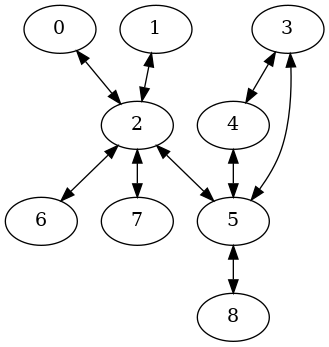

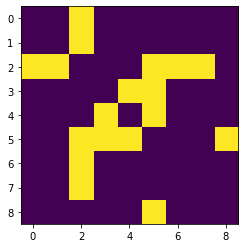

Graph has 1 connected components.


In [72]:
from util import notebook_plot_connectivity
notebook_plot_connectivity(regions, plot_dot=True, plot_adj_mat=True)

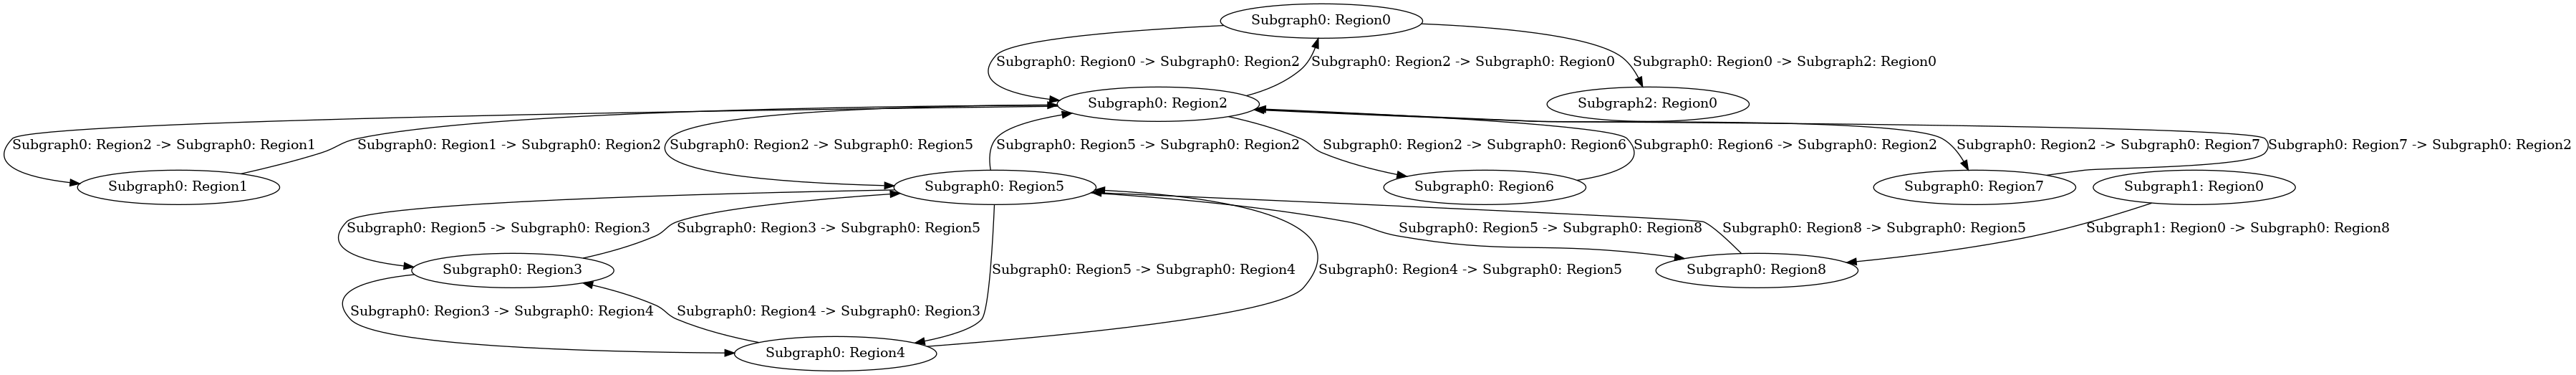

In [73]:
from IPython.display import display, Image, SVG
import pydot
s = gcs.GetGraphvizString()
display(
        Image(
            pydot.graph_from_dot_data(s)[0].create_png()
        )
    )


In [92]:
ORDER = order
gcs, flows_result = generate_flows(start, goal, ORDER, regions, dim=7)
print("flow generated")
start_vertex, end_vertex = prune(gcs, flows_result, epsilon=0.00001)
print("pruned")
best_path, best_rounded_result = run_dfs(flows_result, gcs, start_vertex, end_vertex, iterations=5)

INFO:drake:Solved GCS shortest path using Mosek with convex_relaxation=false and preprocessing=true and no rounding.


flow generated
Start vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x7e40acbfbf70>   and end vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x7e40acbf8af0>
pruned
ITERATION 0
Subgraph1: Region0
Subgraph1: Region0 ['Subgraph0: Region3']
Subgraph0: Region3
Subgraph0: Region3 ['Subgraph0: Region4', 'Subgraph0: Region5']
[0.9999935693400497, 6.430659950318329e-06] 0.3466907928029984
Subgraph0: Region4
Subgraph0: Region4 ['Subgraph0: Region5']
Subgraph0: Region5
Subgraph0: Region5 ['Subgraph0: Region2', 'Subgraph0: Region8']
[1.0, 0.0] 0.20859877818832695
Subgraph0: Region2
Subgraph0: Region2 ['Subgraph0: Region0', 'Subgraph0: Region1', 'Subgraph0: Region6', 'Subgraph0: Region7']
[1.0, 0.0, 0.0, 0.0] 0.7249366447631664
Subgraph0: Region0
Subgraph0: Region0 ['Subgraph2: Region0']
True
found a successful path?
ITERATION 1
Subgraph1: Region0
Subgraph1: Region0 ['Subgraph0: Region3']
Subgraph0: Region3
Subgraph0: Region3 ['Subgraph0: 

In [13]:
print(best_rounded_result)

In [14]:
list(flows_result.get_x_val())

[1.0,
 0.04434430997407868,
 -0.24844808342298963,
 -0.49967597404643177,
 0.0521050131183828,
 -0.1521060338101255,
 0.05222444497283677,
 -0.013667514207940691,
 0.04434436193338955,
 -0.2484480851602353,
 -0.4996759601223839,
 0.052105032668201934,
 -0.1521060379738707,
 0.05222444117824658,
 -0.013667513678069525,
 0.6445132949163418,
 0.03491514664352626,
 -0.21653865911845832,
 -0.15955934379758965,
 -0.08677754284691556,
 0.08417487834545453,
 -0.008931766220377954,
 0.7553713635834363,
 0.08725559695370369,
 -0.16424004307684742,
 -0.19865617637246147,
 -0.07471062421643065,
 0.0900764634626293,
 -0.00805702687706604,
 1.4594338460321543,
 0.41967228438854903,
 0.16791134139211464,
 -0.4469611501553982,
 0.001926745573538445,
 0.12755808583857145,
 -0.00250136872723129,
 1.4594339876391584,
 0.4196723949333875,
 0.16791140141986097,
 -0.44696121958700114,
 0.0019267668510266664,
 0.12755809260138296,
 -0.002501367415890782,
 0.1,
 1.4594339876391584,
 0.4196723949333875,
 0.167

In [93]:
# # setup for PGD
variables, indices, h_list = generate_variable_list(best_path, ndim=7, order=ORDER)
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)

import numpy.linalg as la
# # iterate until infeasible.
# # get constraints and put into HPolyhedron - should be the same as 
prog, _ = prog_with_constraints(variables, best_path, start, goal, indices, 7, h_list)

In [94]:
print("program set")
hpoly = HPolyhedron(prog)
# is A necessary?
A = hpoly.A()
b = hpoly.b()
# create affine subspace
A_eq, b_eq = get_equality_matrices(prog)
U, S, V = la.svd(A_eq)

# nullspace is spanned by the last n-r columns of V
# rank is almost zero entries along the diagonal of S
r = (S>0.00001).sum()
basis = V[r:]
translation = la.pinv(A_eq).dot(b_eq)

affine_sub = AffineSubspace(basis.T, translation)

program set


## Running PGD

In [95]:
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
#         print("Getting gradients")
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    df_Rk = np.asarray(df_Rk)
#     print("got initial gradients and costs ", f_Rk, df_Rk)

    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        t = 10.0
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
#         print("in backtracking, f_k determined to be ", f_k, "Max optimal is", (f_Rk - 0.5*t*(L_norm)))
#         print("in backtracking, while condition is ", f_k > (f_Rk - 0.5*t*(L_norm)))
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
#             print("checkingwhat step to use f_k = ", f_k, "Will it work against ", f_Rk - 0.5*t*(L_norm))
            t2 = time.perf_counter()
        print('Found step size, ', t)

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [96]:
t1_start = perf_counter() 
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)
 
iters = 50
eps = 1e-7
qps_solved = 0
iter_costs = []
x_axis = []
times = []
t_grads = []
t_bt = []
t_qp = []
bt_costs = []
time_steps = []
lnorms = []
running_qp_project = []
termin = []
total_ts = []
costs_ts = []
qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, 7, h_list)
init_values, qp_c = run_qp_proj(variables, init_values, best_path, start, goal, indices, h_list, qp)
print('setup')

setup


In [31]:
from jax import grad
import jax
# define costfn
jax.clear_caches()
costfn = jax.jit(distance_for_vertex, backend="cpu")
t1 = perf_counter()
costfn(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
print("warm start costfn took ", t2 - t1)

warm start costfn took  0.5762066010001945


In [32]:
grad_cost = grad(distance_for_vertex)
grad_jit = jax.jit(grad_cost, backend='cpu')
t1 = perf_counter()
grad_jit(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
t2 - t1

5.989730876000067

In [97]:
investigative_trajs = []
exp_avg = 0
moving_avg = 0
diff_termin = []
window = 5
i = 0
while i < 500:
    total_start = perf_counter()
    grad_time = perf_counter()
#     print('.')
#     bt_cost, bt_time, ts, l_norm = 0, 0, 0, 0
    print("old value", init_values)
    init_values[:len(variables)], bt_cost, bt_time, ts, l_norm = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.01, backtracking=True, ndim=7)
    print("EXPECTED COST", bt_cost)
    print("new value", init_values)
#     init_values[:len(variables)] = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.005, backtracking=False)
    grad_time_stop = perf_counter()
#     print(grad_time_stop - grad_time)
    #### NOT TIMED #####
    t_grads.append(grad_time_stop - grad_time)
    t_bt.append(bt_time)
    bt_costs.append(bt_cost)
    time_steps.append(ts)
    lnorms.append(l_norm)
    ## NOT TIMED FIN ##
    qp_time = perf_counter()
    cheap_proj = affine_sub.Projection(init_values)[1].T[0] # DOUBLE CHECK THE SHAPE OF THIS
    if not hpoly.PointInSet(cheap_proj):
        print("QP RUN")
        init_values, qp_c = run_qp_proj(variables, cheap_proj, best_path, start, goal, indices, h_list, qp, qp_c)
        qps_solved += 1
        running_qp_project.append(True)
    else:
        print("Cheap affine projection worked")
        init_values = cheap_proj
        running_qp_project.append(False)
    print("Post projection values", init_values)
    qp_time_stop = perf_counter()
    #### NOT TIMED #####
    t_qp.append(qp_time_stop - qp_time)
    cost = 0
    cost_calc_start = perf_counter()
    for v in range(len(best_path[1:-1])):
        cost += costfn(init_values[indices[v][0]:indices[v][1]])
        if cost!=cost:
            print(v, i)
    iter_costs.append(cost)
    if len(iter_costs) >= window:
        moving_avg_new = sum(iter_costs[-window:])/window
        termin.append(moving_avg_new)
        if moving_avg != 0:
            diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
        moving_avg = moving_avg_new
#     exp_avg_new = alpha * cost + (1-alpha) * exp_avg
#     exp_avg = exp_avg_new
#     if len(iter_costs) > 4:
#         moving_avg_new = sum(iter_costs[-5:])/5
#         termin.append(moving_avg_new)
#         diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
#         moving_avg = moving_avg_new
    cost_calc_stop = perf_counter()
    costs_ts.append(cost_calc_stop-cost_calc_start)
    x_axis.append(i)
    times.append(perf_counter()-t1_start)
    if i % 10 == 0:
#         qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, h_list)
        print("     ")
    print('.', end='')
    ## NOT TIMED FIN ##
    total_end = perf_counter()
    total_ts.append(total_end-total_start)
    i += 1
#     if i>70:
#         investigative_trajs.append(trajectorify_given_vars(best_path, init_values, indices))
#     else if i==79:
        
t1_stop = perf_counter() 
cost = 0
for v in range(len(best_path[1:-1])):
    cost += costfn(init_values[indices[v][0]:indices[v][1]])
times.append(perf_counter()-t1_start)
iter_costs.append(cost)
x_axis.append(i)

print("Solve time:", t1_stop - t1_start, "QPs run", qps_solved, "iteration_costs", iter_costs)

old value [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5523416457483974, 0.7597313231155468, -0.2319294867502818, -0.4824308478788456, 0.21332969201645122, 0.7021940432785461, -0.005425070414368679, -1.5214002159197435, 0.7433697951815929, -0.23187027189923826, -0.5050842200080027, 0.2022748314408942, 0.6743514017977879, -0.006597865671091377, -1.4906137878738024, 0.7270796883519508, -0.23181276980978638, -0.5276218267884144, 0.19127641254104039, 0.6466466594030443, -0.007764855194397979, -1.3658225517600326, 0.6609805142709793, -0.23161941497731106, -0.6188785609942771, 0.14660875632888612, 0.5343186997458774, -0.012496341164977396, -1.3657872042749775, 0.6609731110361926, -0.2315762346480159, -0.618928605608932, 0.14652696612044558, 0.5342267552820353, -0.012497656015559877, -1.3658174253880586, 0.6609619731286595, -0.23161385730902626, -0.6190702439457704, 0.14665056382590144, 0.5342417573199536

Post projection values [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.549954669998583, 0.762693365537717, -0.23333798238805983, -0.47453281929619257, 0.21554592061333688, 0.6960710324762406, -0.005107030489291462, -1.5190221978321232, 0.7463257149789374, -0.23388653925188996, -0.4977412801168377, 0.20513664112082605, 0.668464941917069, -0.006209302876815365, -1.487933981597767, 0.7306363761797182, -0.23523846502176457, -0.519862451763885, 0.1957337260182, 0.6402411715605041, -0.007135414434851027, -1.3623921031565587, 0.6663754342761586, -0.23934617928841323, -0.6100562581893427, 0.1556451154236449, 0.5266430131008308, -0.011261164278624662, -1.3562811468540346, 0.6637759227826121, -0.24030070846111184, -0.6135452097317372, 0.15416083324485155, 0.5240593704676948, -0.012991117765558143, -1.3608458198069455, 0.6638367191528837, -0.23582101326708593, -0.6138423360808468, 0.14973211329496436, 0.52707664

     
.old value [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5482173219194406, 0.7647133089195439, -0.2351555503608115, -0.4702949117182395, 0.2181696806437765, 0.6928380604898927, -0.004852861681308958, -1.517246838210767, 0.7483036376251796, -0.23597599961480947, -0.4937565493384013, 0.20786720128246877, 0.6654545713344497, -0.006445649317192648, -1.4859627555476906, 0.7328588070265176, -0.2374655433346805, -0.5152646126098953, 0.19862423058529813, 0.6372660982885664, -0.008615749383934244, -1.3601365033204849, 0.6691277523177444, -0.24279817955371294, -0.6050136657148107, 0.1598253675121664, 0.5247110231215767, -0.015484329342895772, -1.3522922049060282, 0.6655056855997636, -0.24409382148636147, -0.6104418706615333, 0.15835283925931865, 0.5179767978531689, -0.0013770584158416322, -1.356735703873183, 0.6665168138404222, -0.24044293296526587, -0.610527009777389, 0.1536833698856714, 0.521884606033

Post projection values [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5466553369154932, 0.7662032077719463, -0.2366216008406438, -0.4672123855648993, 0.2204512853991749, 0.6909404475897714, -0.004397890703023623, -1.5157781782384274, 0.7499025282069325, -0.23778885139370398, -0.4906672964942456, 0.21035538111754906, 0.6639044926575659, -0.004603780171868276, -1.484983903732477, 0.7354673850705701, -0.23938013656235924, -0.5101541436745418, 0.20187713050145206, 0.6368752430783915, -0.0034718423896746083, -1.3609026233780401, 0.6744278208172975, -0.24532824344660734, -0.5954157106743793, 0.1662250342102366, 0.5298605657729312, -0.003369602819516229, -1.3486469006918007, 0.6666010041933191, -0.24767060555915194, -0.6084728590120753, 0.1611989645565986, 0.5146331027679604, -0.02936700438399999, -1.351538448114592, 0.6652418395793572, -0.24374218784361248, -0.6092857858787449, 0.1580504848127566, 0.516154

Post projection values [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5448882285512646, 0.7675436355036713, -0.23802478703316332, -0.46439074479636866, 0.2225114531256803, 0.6897656580392639, -0.004179832331997352, -1.5142795146885617, 0.7513069124736885, -0.239570092544027, -0.4880605514996944, 0.21260515807859492, 0.6630535476520758, -0.004737743002559408, -1.4844855431216006, 0.7378208230230798, -0.24129429644164502, -0.5057855584275459, 0.20451795872096054, 0.636453629124864, -0.004445093539471917, -1.3631252497253739, 0.6789962771735992, -0.2478737454608956, -0.5876583597434324, 0.17055526798072143, 0.5330636135947502, -0.0058377540898464425, -1.3455606602850034, 0.6674234001435005, -0.25036379380618407, -0.6068540153799322, 0.1633968335793261, 0.5114552597422234, -0.021454872441294515, -1.3454163582102208, 0.6635617182916621, -0.24722360222082987, -0.6080781791615217, 0.16130162881643667, 0.511

...

.old value [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5368587630788666, 0.7711685302184498, -0.2415870958185264, -0.4549645887027088, 0.2277303952612165, 0.6902888844572934, -0.00271696739871595, -1.5091464944119501, 0.7528353296348599, -0.24484544902692987, -0.48572327809074334, 0.21671354387790992, 0.6649492155459644, -0.003599774255304387, -1.4746680383590307, 0.7427448649422723, -0.246002619385753, -0.49286698809775314, 0.21090638420648775, 0.6342819709128341, -0.0039839686897390585, -1.3633367705916197, 0.6838698679389731, -0.2556642894633859, -0.5807327469133812, 0.1765171258730395, 0.5314171889993604, -0.006651818467777196, -1.3361339573165547, 0.6688202145591247, -0.2581392095629794, -0.6036267319518706, 0.16785438061169491, 0.5051977988825368, -0.007329499300425389, -1.302914312831789, 0.6292971906084857, -0.2589643422724288, -0.616754930726873, 0.1726616195600208, 0.4893064317909884, -0

Found step size,  0.0390625
EXPECTED COST 7.107876
new value [-1.68896319665654, 0.8212911065381441, -0.2374716367788333, -0.4142184827129447, 0.2446859885028132, 0.8004522299291618, -0.001678795670159161, -1.5368888836777586, 0.7709747491899941, -0.24161402072975166, -0.4548899113975496, 0.22776644835232895, 0.6902953196889146, -0.0027164763964193164, -1.5092029876119442, 0.7526209978836456, -0.24487551271555474, -0.48565394616930657, 0.21674830028553954, 0.6649399067010985, -0.0036001942718593216, -1.4746996591790837, 0.7424963226235446, -0.24603705670230652, -0.49276813128179003, 0.21095317907250305, 0.6342916051329961, -0.003985590799241164, -1.3633977841254659, 0.6835898455557505, -0.2557016944934566, -0.5806307482988222, 0.17656843873049205, 0.531418318205683, -0.006656203055508096, -1.3371752381764739, 0.6444286474600127, -0.255787217519217, -0.5954057628211146, 0.1988570859787862, 0.52214114784075, -0.006920173069923861, -1.303132280985035, 0.6285636569083618, -0.25941481015707

Post projection values [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5368559343225885, 0.7711225860650421, -0.24159097568506313, -0.4549434397645099, 0.22774071652152775, 0.6902995251208005, -0.002715485720360041, -1.5091838987536945, 0.752793438873627, -0.2448488366097583, -0.4857273568334208, 0.2167141040131832, 0.664931308898144, -0.003599197413756031, -1.4746467509362677, 0.7427137746692131, -0.246002988313585, -0.49284550527643084, 0.21091579945418823, 0.6342988015853834, -0.003984028882301901, -1.3633571489867884, 0.68384729084869, -0.2556608512983858, -0.5807290278849399, 0.17652179949500815, 0.531419192910974, -0.0066537951376335475, -1.336147345333723, 0.6688194832614458, -0.2581288517268802, -0.6036294220140963, 0.16785074767928246, 0.5052033303572014, -0.0073513514325259455, -1.302746145904032, 0.6289871926447896, -0.2589352159077856, -0.6168836234319516, 0.17276906480348891, 0.4892757360

Post projection values [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5368434334240184, 0.7711594642137494, -0.24158415192567442, -0.45495468980264925, 0.22773400899927165, 0.6903041439548548, -0.002715765878513317, -1.509193834215751, 0.7528268966386346, -0.24484259861588764, -0.4857496110567463, 0.21670294264473508, 0.6649209812480864, -0.0036011199731821016, -1.474627505001991, 0.7427443218858082, -0.24599638904948212, -0.4928514585945126, 0.2109102175052071, 0.6343074126872248, -0.003988546266987127, -1.3633621490502839, 0.6838752642986168, -0.2556538417335283, -0.5807403394103832, 0.17651257288904396, 0.5314208887897531, -0.006663551754281177, -1.3361450275067344, 0.6688203992225887, -0.2581304748423355, -0.6036276649453347, 0.1678524317094671, 0.5051988077384396, -0.007310374352820886, -1.3026636322529548, 0.6288464606764534, -0.25894829952564674, -0.6170169305340141, 0.17276657930100042, 0.489

Post projection values [-1.6954947197314947, 0.8352858310278926, -0.23222289599773469, -0.37759223688646193, 0.2644908070585259, 0.8309888629140384, 0.0, -1.5368338554928875, 0.7711767423156147, -0.2415815970957783, -0.45495724475572996, 0.2277319062222347, 0.6903083636857297, -0.0027145358489892267, -1.5092061534861199, 0.7528411197520483, -0.2448407798874272, -0.48576301197204524, 0.2166969385938693, 0.6649104402898336, -0.003598420672087427, -1.4746110380265625, 0.742756502930602, -0.24599459240876237, -0.4928493457191737, 0.2109106097726556, 0.634315110829705, -0.003982263766485881, -1.363368760363428, 0.6838859901853095, -0.25565279535033864, -0.5807431540584073, 0.17651146563042125, 0.5314212585752074, -0.006651041132659739, -1.3361448823925854, 0.6688191495958102, -0.25813005069612566, -0.6036295907393522, 0.1678497952699337, 0.5052028070656032, -0.007325223057045005, -1.3025723577482555, 0.6286960727938181, -0.2589531367691269, -0.6171223763860011, 0.1727797215997183, 0.4891170

In [30]:
traj_pgd = trajectorify_given_vars(best_path, init_values, indices, ndim=7)
traj_og = trajectorify_given_vars(best_path, [best_rounded_result.GetSolution(x) for x in variables], indices, ndim=7)

NameError: name 'best_path' is not defined

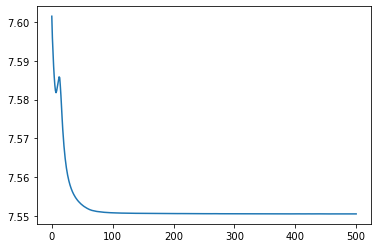

In [99]:
import matplotlib.pyplot as plt
plt.plot(np.arange(len(iter_costs)), iter_costs)

In [247]:
best_path

In [29]:
from util import remap_and_toppra_trajectory, build_env, plot_traj_end_effector_path
from pydrake.all import MultibodyPositionToGeometryPose, TrajectorySource, Simulator, InverseKinematics
import jaxutil as ju #from analytic_ik import Analytic_IK_7DoF, iiwa_alpha, iiwa_d, iiwa_limits_lower, iiwa_limits_upper
analytic_ik = ju.Analytic_IK_JAXLESS(ju.iiwa_alpha, ju.iiwa_d, ju.iiwa_limits_lower, ju.iiwa_limits_upper)

def remap(s):
    return Ratfk.ComputeQValue(s, q_star)

gcs_traj_pgd = remap_and_toppra_trajectory(traj_pgd, remap, plant)
breaks_new = np.linspace(0, gcs_traj_pgd.end_time(), int(1e3), endpoint=False)
knots_full = gcs_traj_pgd.vector_values(breaks_new)

gcs_traj_og = remap_and_toppra_trajectory(traj_og, remap, plant)
breaks_new_og = np.linspace(0, gcs_traj_og.end_time(), int(1e3), endpoint=False)
knots_full_og = gcs_traj_og.vector_values(breaks_new_og)

# knots_full = np.array([remap(knot) for knot in knots_latent.T]).T

builder = DiagramBuilder()

subdiagram, plant, scene_graph = build_env(meshcat, directives_file, export_sg_input=True)
builder.AddNamedSystem("env_diagram", subdiagram)
pose_info = MultibodyPositionToGeometryPose(plant)
plot_traj_end_effector_path(knots_full.T, meshcat, analytic_ik)
plot_traj_end_effector_path(knots_full_og.T, meshcat, analytic_ik, name="og", color_rgba=(1, 1, 1, 1))
to_pose = builder.AddSystem(pose_info)
builder.Connect(to_pose.get_output_port(), subdiagram.GetInputPort("source_pose"))

traj_system = builder.AddSystem(TrajectorySource(gcs_traj_pgd))
builder.Connect(traj_system.get_output_port(), to_pose.get_input_port())

diagram = builder.Build()

meshcat_visual = diagram.GetSubsystemByName("env_diagram").GetSystems()[1]

simulator = Simulator(diagram)
meshcat_visual.StartRecording()
simulator.AdvanceTo(gcs_traj_og.end_time() + 0.1)
meshcat_visual.PublishRecording()

NameError: name 'traj_pgd' is not defined

In [75]:
gcs_traj_og.end_time(), gcs_traj_pgd.end_time()

(7.017921993214939, 7.154511793668461)

In [80]:
gcs_traj = remap_and_toppra_trajectory(traj, remap, plant)
breaks_new = np.linspace(0, gcs_traj.end_time(), int(1e3), endpoint=False)
knots_latent = gcs_traj.vector_values(breaks_new)

knots_full = np.array([remap(knot) for knot in knots_latent.T]).T

diagrams, plants = plot_traj_swept_volume(knots_full.T, build_env, meshcat, directives_file, count=2, alpha=0.15)
plot_traj_end_effector_path(knots_full.T,
                            meshcat,
                            analytic_ik)

meshcat.SetCameraPose([-1, 0.3825, 0.75], [0, 0.3825, 0.25])
render_trajectory(meshcat, build_env, directives_file, gcs_traj, save=True, fname="nonconvex_cost.html")

latent_traj_len = np.sum(np.linalg.norm(knots_latent[:,1:] - knots_latent[:,:-1], axis=0))
true_traj_len = np.sum(np.linalg.norm(knots_full[:,1:] - knots_full[:,:-1], axis=0))
print("GCS Latent Path Length: %f" % latent_traj_len)
print("GCS True Path Length: %f" % true_traj_len)

right_len = np.sum(np.linalg.norm(knots_full[7:,1:] - knots_full[7:,:-1], axis=0))
left_len = np.sum(np.linalg.norm(knots_full[:7,1:] - knots_full[:7,:-1], axis=0))
print(f"Arm 1 path length: {right_len}")
print(f"Arm 2 path length: {left_len}")
print(f"pretty metric: {(right_len-left_len)/left_len}")

reachability_errs = [reachability_constraint_violation(point[:7], point[7:], analytic_ik, FK_fun) for point in knots_full.T]
print("Maximum reachability distance error: %f" % np.max(reachability_errs))
plt.plot(reachability_errs)
plt.show()

with open(RepoDir() + "/data/q_full_path.pickle", "wb") as f:
    pickle.dump(knots_full.T, f)

NameError: name 'traj' is not defined

In [ ]:
len(best_path)

In [ ]:
# dumb init
pts = np.squeeze(np.array([np.arctan(traj.value(it * traj.end_time() / 100)) for it in range(100)]))

In [ ]:
# np.hstack([pts, 0 * np.ones((pts.shape[0], 3 - pts.shape[1]))]).T
pts.shape

In [98]:
# # visualize path given trajectory
import visualization_utils as viz_utils
# viz_utils.draw_traj(visualizer.meshcat_cspace, traj, 100)
# viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj, 100, q_star=q_star)
# visualizer.animate_traj_s(traj, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_og, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_og, 100, q_star=q_star)
visualizer.animate_traj_s(traj_og, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_pgd, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_pgd, 100, q_star=q_star)
visualizer.animate_traj_s(traj_pgd, 100, 100)

## Validating Paths?

In [106]:
# take a path
# calculate the q value at each point along the trajectory
# Sum all of them
def length_of_traj(traj):
    q_prev = start_q
    dist = 0
    for i in range(50):
        s = traj.value(traj.end_time()*i/50)
        q = Ratfk.ComputeQValue(s, q_star)
        dist += ((q - q_prev).dot(q - q_prev))**0.5
        q_prev = q
    return dist
new_len = length_of_traj(traj_pgd)
og_len = length_of_traj(traj_og)
print(new_len, og_len)

7.54364600906225 8.641229878292995


In [107]:
(og_len - new_len) / og_len

0.12701708954507795

In [108]:
q_star

array([0., 0., 0., 0., 0., 0., 0.])

In [109]:
traj_og.end_time()

2.0

In [110]:
traj_pgd.end_time()

2.0

In [56]:
iter_dist = 0
values = init_values
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [57]:
iter_dist

Array(3.3586519, dtype=float32)

In [58]:
iter_dist = 0
values = [best_rounded_result.GetSolution(x) for x in variables]
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [59]:
iter_dist

Array(3.3597455, dtype=float32)

In [99]:
q_star

array([1., 1.])

## 7 DOF IIWA

In [5]:
#construct our robot
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)

parser.package_map().Add("ciris_pgd", os.path.abspath(''))

directives_file = "/home/sgrg/rlg/SUPERUROP/ciris/models/iiwa14_sphere_collision_complex_scenario.dmd.yaml"
directives = LoadModelDirectives(directives_file)
models = ProcessModelDirectives(directives, plant, parser)


# oneDOF_iiwa_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/oneDOF_iiwa7_with_box_collision.sdf"
# with open(one|DOF_iiwa_file, 'r') as f:
#     oneDOF_iiwa_string = f.read()
# box_asset_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/box_small.urdf"
# with open(box_asset_file, 'r') as f:
#     box_asset_string = f.read()

In [45]:
e = traj_og.end_time()
for i in range(100):
    print(traj_og.value(e*i/100))

[[-1.69549472e+00]
 [ 8.35285831e-01]
 [-2.32222896e-01]
 [-3.77592237e-01]
 [ 2.64490807e-01]
 [ 8.30988863e-01]
 [-9.35905537e-07]]
[[-1.66237428e+00]
 [ 8.17792917e-01]
 [-2.32156676e-01]
 [-4.01845435e-01]
 [ 2.52655238e-01]
 [ 8.01188546e-01]
 [-1.25616175e-03]]
[[-1.6340342 ]
 [ 0.80282381]
 [-0.23210015]
 [-0.42259789]
 [ 0.24252803]
 [ 0.77568924]
 [-0.00233022]]
[[-1.60966807]
 [ 0.78995247]
 [-0.23205172]
 [-0.44044009]
 [ 0.23382103]
 [ 0.75376535]
 [-0.00325369]]
[[-1.58850502]
 [ 0.77877155]
 [-0.23200986]
 [-0.45593648]
 [ 0.22625879]
 [ 0.73472326]
 [-0.00405577]]
[[-1.56982076]
 [ 0.7688983 ]
 [-0.23197318]
 [-0.46961738]
 [ 0.21958249]
 [ 0.71791124]
 [-0.00476391]]
[[-1.55294871]
 [ 0.75998039]
 [-0.23194035]
 [-0.48197087]
 [ 0.21355398]
 [ 0.7027295 ]
 [-0.00540339]]
[[-1.537291  ]
 [ 0.75170183]
 [-0.23191023]
 [-0.4934347 ]
 [ 0.20795961]
 [ 0.68864007]
 [-0.00599686]]
[[-1.52232957]
 [ 0.74378879]
 [-0.2318818 ]
 [-0.50438817]
 [ 0.20261429]
 [ 0.67517679]
 [-0.0